In [8]:
import numpy as np
from typing import Optional, Union, Any
from sklearn.base import BaseEstimator
from numpy.typing import NDArray
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

Формула

In [19]:
class KDE(BaseEstimator):
    def __init__(self, bandwidth: float = 1.0) -> None:
        self.bandwidth: float = bandwidth
        self.data: Optional[NDArray[np.float64]] = None

    def fit(self, X: NDArray[np.float64], y: Optional[Any] = None) -> 'KDE': # не уверен, что именно так задаются классы в typing, но вроде работает
        self.data = np.array(X, dtype=np.float64)
        return self

    def predict(self, X: NDArray[np.float64]) -> NDArray[np.float64]: # Да, криво, зато в одну строчку; в сноске - развернуто
        return np.mean(np.exp(-0.5 * np.sum(((self.data[:, np.newaxis] - X[np.newaxis, :]) / self.bandwidth) ** 2, axis=2)), axis=0) / (self.bandwidth * np.sqrt(2 * np.pi)) # в одну строчку не получилось...

predict (не в одну строчку)
```
    def predict(self, X: NDArray[np.float64]) -> NDArray[np.float64]:
        X = np.array(X)
        distances = np.sum(((self.data[:, np.newaxis] - X.T) / self.bandwidth) ** 2, axis=0)
        density = np.mean(np.exp(-0.5 * distances), axis=0) / (self.bandwidth * np.sqrt(2 * np.pi))
            
        return density
```

Данные

In [20]:
np.random.seed(42)
X = np.random.randn(100, 2)
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
xx, yy = np.meshgrid(x, y)
grid = np.c_[xx.ravel(), yy.ravel()]

Fit-predict

In [21]:
# Наша реализация
my_kde = KDE(bandwidth=1.0)
my_kde.fit(X)
my_density = my_kde.predict(grid).reshape(xx.shape)

sklearn_kde = KernelDensity(bandwidth=1.0, kernel='gaussian')
sklearn_kde.fit(X)
sklearn_density = np.exp(sklearn_kde.score_samples(grid)).reshape(xx.shape)


Визуализация

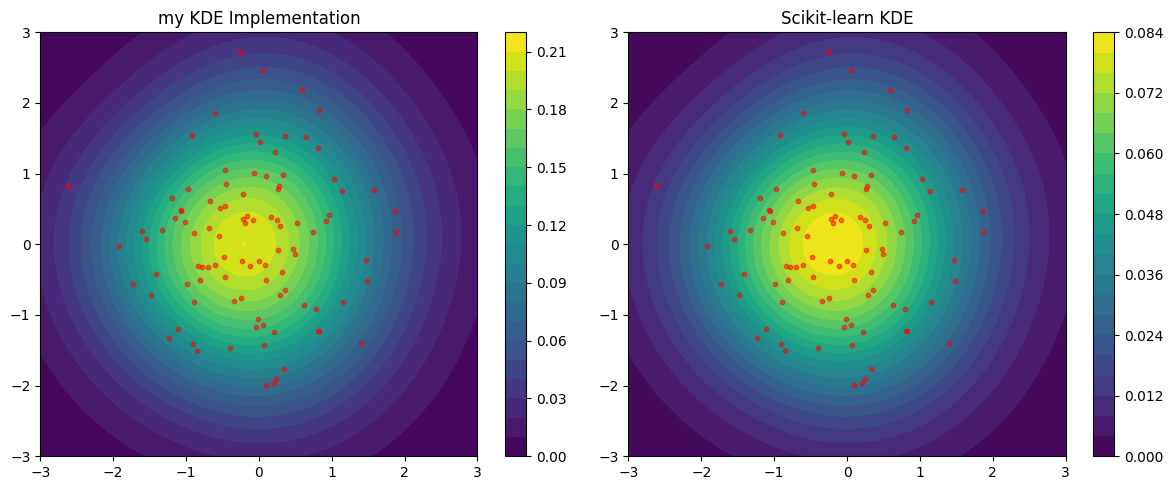

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

im1 = ax1.contourf(xx, yy, my_density, levels=20)
ax1.scatter(X[:, 0], X[:, 1], c='red', s=10, alpha=0.5)
ax1.set_title('my KDE Implementation')
plt.colorbar(im1, ax=ax1)

im2 = ax2.contourf(xx, yy, sklearn_density, levels=20)
ax2.scatter(X[:, 0], X[:, 1], c='red', s=10, alpha=0.5)
ax2.set_title('Scikit-learn KDE')
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

In [18]:
print("Max difference between implementations:", np.max(np.abs(my_density - sklearn_density)))
print("Mean difference between implementations:", np.mean(np.abs(my_density - sklearn_density)))

Max difference between implementations: 0.126247629745193
Mean difference between implementations: 0.0388547056778406
